# ICU Mortality Prediction: Specialist vs Global vs APACHE-IVa

This notebook tests whether ICU-type-specific mortality models outperform a single pooled model and the APACHE-IVa benchmark on the WiDS 2020 / GOSSIS dataset.

The pipeline runs APACHE-IVa as the comparator, then a class-weighted logistic regression, then a tuned global XGBoost, then eight specialist XGBoosts (one per ICU type). I add isotonic calibration on the global XGB, paired bootstrap CIs across all five models on the APACHE-available test cohort, and follow up with SHAP, threshold metrics, decision-curve analysis and a subgroup-fairness audit.

A few notes on reproducibility. Seed is fixed at 42 throughout. XGBoost has to be ≥ 2.0, the early-stopping API moved into the constructor in 2.0. The training CSV has to be loaded with `engine='python'` because the default C parser silently dropped about 30,000 rows on the first run. There's now a row-count assert that fails loudly if anything similar happens again. All numerical outputs are saved to a single `results_summary.json` so the report pulls from one source.

## Cell 1 - Setup, imports, seed

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression

import xgboost as xgb

# XGBoost >= 2.0 required: early_stopping_rounds moved to the constructor.
xgb_major = int(xgb.__version__.split('.')[0])
assert xgb_major >= 2, (
    f"XGBoost {xgb.__version__} is too old; this pipeline requires >=2.0. "
    "Run: pip install --upgrade xgboost"
)

# Optional but recommended -- SHAP. If missing, Section 12 is skipped gracefully.
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed; SHAP cell will be skipped. "
          "Run `pip install shap` to enable.")

SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = "."
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAINING_PATH = "training_v2.csv"
if not os.path.exists(TRAINING_PATH):
    raise FileNotFoundError(
        f"'{TRAINING_PATH}' not found. Download from "
        "https://www.kaggle.com/competitions/widsdatathon2020/data "
        "and upload to the Colab sidebar (or place beside this notebook locally)."
    )

# The default C parser silently truncates this file at ~62k of 91,713 rows
# engine='python' is ~3x slower but robust. We assert the expected row count so
# any future silent truncation fails LOUDLY.
EXPECTED_ROWS = 91_713
df = pd.read_csv(TRAINING_PATH, engine='python')
assert df.shape[0] == EXPECTED_ROWS, (
    f"Loaded {df.shape[0]:,} rows but expected {EXPECTED_ROWS:,}. "
    "Dataset has been modified or truncated -- do not proceed."
)

plt.rcParams.update({"figure.figsize": (8, 5), "figure.dpi": 110})
warnings.filterwarnings("ignore", category=FutureWarning)
print(f"XGBoost {xgb.__version__}; SHAP available: {SHAP_AVAILABLE}")
print(f"Loaded {df.shape[0]:,} rows from {TRAINING_PATH}.")


XGBoost 2.1.0; SHAP available: True
Loaded 91,713 rows from training_v2.csv.


## Cell 2 - Sanity checks, APACHE −1 → NaN, mortality by ICU type

In [2]:
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"In-hospital mortality rate: {df['hospital_death'].mean()*100:.2f}%")

# APACHE -1 is a placeholder for "missing"; treating it as a probability would
# silently corrupt brier_score_loss and roc_auc_score downstream.
df.loc[df['apache_4a_hospital_death_prob'] < 0, 'apache_4a_hospital_death_prob'] = np.nan
df.loc[df['apache_4a_icu_death_prob']     < 0, 'apache_4a_icu_death_prob']     = np.nan
print(f"APACHE-IVa missing in {df['apache_4a_hospital_death_prob'].isna().sum():,} "
      f"rows ({df['apache_4a_hospital_death_prob'].isna().mean()*100:.1f}%)")

print(f"\nICU types ({df['icu_type'].nunique()} unique):")
print(df['icu_type'].value_counts())

# Does in-hospital mortality actually differ across the eight ICU types?
# This is the clinical premise behind examining unit-specific models.
# If mortality were uniform across units, there would be no signal for
# specialisation to exploit in the first place.
print("\nMortality by ICU type:")
print(df.groupby('icu_type')['hospital_death'].agg(['mean', 'count']).round(4))


Loaded: 91,713 rows × 186 columns
In-hospital mortality rate: 8.63%
APACHE-IVa missing in 10,318 rows (11.3%)

ICU types (8 unique):
icu_type
Med-Surg ICU    50586
MICU             7695
Neuro ICU        7675
CCU-CTICU        7156
SICU             5209
Cardiac ICU      4776
CSICU            4613
CTICU            4003
Name: count, dtype: int64

Mortality by ICU type:
                mean  count
icu_type                   
CCU-CTICU     0.0757   7156
CSICU         0.0551   4613
CTICU         0.0602   4003
Cardiac ICU   0.1034   4776
MICU          0.1209   7695
Med-Surg ICU  0.0875  50586
Neuro ICU     0.0831   7675
SICU          0.0749   5209


## Cell 3 — Feature engineering

Four kinds of derived features, each with a clinical reason:

1. **Range** (`d1_max − d1_min`): captures physiological instability over the first 24 hours. A patient whose BP swings from 80 to 180 is in a very different state from one steady at 130, even with a similar mean.
2. **Deterioration** (`d1_max − h1_max` and `d1_min − h1_min`): did the patient get worse over day 1, or stabilise? I compute both the peak deltas (HR, lactate, BUN, where high is bad) and the trough deltas (SpO₂, BP, haemoglobin, where low is bad). Computing only the peak deltas would miss desaturation and hypotension, which are the clinically obvious deteriorations to track.
3. **Comorbidity count**: sum of the eight chronic-disease flags. The individual flags are kept too. The count is just a convenience feature.
4. **Missingness flags**: binary indicators for whether invasive BP, lactate, and arterial blood gas were ordered. Ordering an invasive test signals clinical concern, so the fact of measurement is informative even before the value itself.

Categorical variables are one-hot encoded with `dummy_na=True` so NaN becomes its own column rather than being dropped.

In [3]:
fe = df.copy()
new_cols = {}

# (i) Range features --------------------------------------------------------
for col in fe.columns:
    if col.endswith('_max'):
        base = col[:-4]
        min_col = base + '_min'
        if min_col in fe.columns:
            new_cols[base + '_range'] = fe[col] - fe[min_col]

# (ii) Deterioration features -- BOTH directions ----------------------------
d1_max_cols = [c for c in fe.columns if c.startswith('d1_') and c.endswith('_max')]
for d1c in d1_max_cols:
    h1c = 'h1_' + d1c[3:]
    if h1c in fe.columns:
        new_cols[d1c[3:-4] + '_max_delta'] = fe[d1c] - fe[h1c]

d1_min_cols = [c for c in fe.columns if c.startswith('d1_') and c.endswith('_min')]
for d1c in d1_min_cols:
    h1c = 'h1_' + d1c[3:]
    if h1c in fe.columns:
        new_cols[d1c[3:-4] + '_min_delta'] = fe[d1c] - fe[h1c]

# (iii) Comorbidity count ---------------------------------------------------
COMORBIDITIES = [
    'aids', 'cirrhosis', 'diabetes_mellitus', 'hepatic_failure',
    'immunosuppression', 'leukemia', 'lymphoma', 'solid_tumor_with_metastasis',
]
new_cols['comorbidity_count'] = fe[COMORBIDITIES].sum(axis=1)

# (iv) Missingness-as-signal flags ------------------------------------------
new_cols['had_invasive_BP']        = fe['d1_diasbp_invasive_max'].notna().astype(int)
new_cols['had_lactate']            = fe['d1_lactate_max'].notna().astype(int)
new_cols['had_arterial_blood_gas'] = fe['d1_arterial_ph_max'].notna().astype(int)

fe = pd.concat([fe, pd.DataFrame(new_cols, index=fe.index)], axis=1)

cat_cols = fe.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns one-hot encoded: {cat_cols}")
fe = pd.get_dummies(fe, columns=cat_cols, dummy_na=True)

print(f"After feature engineering: {fe.shape[1]} columns "
      f"({fe.shape[1] - df.shape[1]} new features)")


Categorical columns one-hot encoded: ['ethnicity', 'gender', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem']
After feature engineering: 378 columns (192 new features)


## Cell 4 - Stratified train/test split

Standard 80:20 split, but stratified jointly on `hospital_death × icu_type` rather than on the outcome alone. If you stratify on mortality only, a small ICU like CTICU can end up with very few deaths in the test set, which makes the per-ICU AUC-PR unstable.

`apache_4a_hospital_death_prob` is held aside as the benchmark and never goes into the feature matrix. APACHE-IVa was itself trained on `hospital_death`, so including it would be straightforward target leakage.

In [4]:
DROP_COLS = [
    'encounter_id', 'patient_id', 'hospital_id', 'icu_id',
    'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob',
    'readmission_status',
]

apache_pred = df['apache_4a_hospital_death_prob'].copy()

X = fe.drop(columns=[c for c in DROP_COLS if c in fe.columns] + ['hospital_death'])
y = fe['hospital_death']

# Joint stratification key
strat_key = df['hospital_death'].astype(str) + '_' + df['icu_type'].fillna('NA')

# Defensive: merge any singleton strata so train_test_split can't fail.
strat_counts = strat_key.value_counts()
singletons = strat_counts[strat_counts < 2].index.tolist()
if singletons:
    modal = strat_counts.index[0]
    print(f"Merging {len(singletons)} singleton strata into '{modal}'")
    strat_key = strat_key.replace(singletons, modal)

X_train, X_test, y_train, y_test, ap_train, ap_test = train_test_split(
    X, y, apache_pred,
    test_size=0.20, stratify=strat_key, random_state=SEED,
)
icu_test = df.loc[X_test.index, 'icu_type'].copy()
ethnicity_test = df.loc[X_test.index, 'ethnicity'].copy()
gender_test    = df.loc[X_test.index, 'gender'].copy()
age_test       = df.loc[X_test.index, 'age'].copy()

print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")
print(f"Train mortality: {y_train.mean()*100:.2f}%   "
      f"Test mortality: {y_test.mean()*100:.2f}%")
print(f"Feature count: {X.shape[1]}")


Train: 73,370   Test: 18,343
Train mortality: 8.63%   Test mortality: 8.63%
Feature count: 370


## Cell 5 - APACHE-IVa benchmark

In [5]:
apache_mask = ~ap_test.isna()
ap_eval = ap_test[apache_mask].values
y_eval_ap = y_test[apache_mask].values

ap_auroc = roc_auc_score(y_eval_ap, ap_eval)
ap_auprc = average_precision_score(y_eval_ap, ap_eval)
ap_brier = brier_score_loss(y_eval_ap, ap_eval)

print(f"APACHE-IVa available for {apache_mask.sum():,} of {len(y_test):,} "
      f"test patients ({apache_mask.mean()*100:.1f}%)")
print(f"=== APACHE-IVa ===")
print(f"  AUC-ROC: {ap_auroc:.4f}")
print(f"  AUC-PR : {ap_auprc:.4f}")
print(f"  Brier  : {ap_brier:.4f}")


APACHE-IVa available for 16,288 of 18,343 test patients (88.8%)
=== APACHE-IVa ===
  AUC-ROC: 0.8642
  AUC-PR : 0.4556
  Brier  : 0.0626


## Cell 6 - Logistic regression baseline

In [6]:
# Class-weighted L2 logistic regression with median imputation + standard
# scaling. Median (not mean) because lab values are heavily right-skewed.
# class_weight='balanced' is the linear-model analogue of XGBoost's
# scale_pos_weight: it re-weights the loss without inventing synthetic patients.
lr_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced',
                                max_iter=2000, random_state=SEED)),
])
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict_proba(X_test)[:, 1]

lr_auroc = roc_auc_score(y_test, lr_pred)
lr_auprc = average_precision_score(y_test, lr_pred)
lr_brier = brier_score_loss(y_test, lr_pred)

print(f"=== Logistic Regression ===")
print(f"  AUC-ROC: {lr_auroc:.4f}")
print(f"  AUC-PR : {lr_auprc:.4f}")
print(f"  Brier  : {lr_brier:.4f}")


=== Logistic Regression ===
  AUC-ROC: 0.8852
  AUC-PR : 0.5018
  Brier  : 0.1340


## Cell 7 - Global XGBoost with RandomizedSearchCV

Tune the global XGBoost with `RandomizedSearchCV`: 30 random configurations from a clinically reasonable grid, scored on AUC-PR (the right metric for 8.6% positives), 5-fold stratified CV inside the training set.

After the search picks the best config, refit at `n_estimators=2000` with early stopping on a held-out validation slice. `scale_pos_weight` is set to the train-set ratio of survivors to deaths (= 10.6) so the model can't get away with predicting "alive" for everyone.

In [7]:
import subprocess
try:
    gpu_info = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader']
    ).decode().strip()
    XGB_DEVICE = 'cuda'
    print(f"GPU detected: {gpu_info} → using device='cuda'")
except (subprocess.CalledProcessError, FileNotFoundError):
    XGB_DEVICE = 'cpu'
    print("No GPU detected → falling back to device='cpu' "
          "(slower but byte-identical results).")

# Inner train/val split for early stopping
X_tr_inner, X_val, y_tr_inner, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=SEED,
)

# scale_pos_weight = n_negative / n_positive (~ 10.6 on this cohort)
spw = float((y_tr_inner == 0).sum() / (y_tr_inner == 1).sum())
print(f"scale_pos_weight: {spw:.2f}")

# --- RandomizedSearchCV --------------------------------------------------
# The grid is constrained to ranges that are clinically defensible and
# computationally tractable. We use a smaller estimator count for the search,
# then refit with early stopping at higher n_estimators.

search_grid = {
    'max_depth':        [3, 4, 5, 6, 7, 8],
    'learning_rate':    [0.02, 0.03, 0.05, 0.08, 0.1],
    'min_child_weight': [1, 3, 5, 10],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_lambda':       [0.5, 1.0, 2.0, 5.0],
    'gamma':            [0, 0.1, 0.5, 1.0],
}

search_estimator = xgb.XGBClassifier(
    n_estimators=300,          # capped for the search; final fit uses more
    scale_pos_weight=spw,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
    device=XGB_DEVICE,              # GPU acceleration
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
search = RandomizedSearchCV(
    estimator=search_estimator,
    param_distributions=search_grid,
    n_iter=30,                  # 30 random configurations
    scoring='average_precision',  # AUC-PR
    cv=cv,
    random_state=SEED,
    n_jobs=1,                   # MUST be 1 with GPU — running folds in parallel
                                # on a single GPU causes memory contention.
    verbose=1,
    refit=False,                # we refit manually with early stopping below
)
print("Running RandomizedSearchCV (5-fold CV × 30 configs) on GPU...")
search.fit(X_tr_inner, y_tr_inner)

best_params = search.best_params_
print(f"\nBest mean AUC-PR (CV): {search.best_score_:.4f}")
print(f"Best params: {best_params}")

# --- Final fit with early stopping at higher n_estimators ----------------
global_xgb = xgb.XGBClassifier(
    n_estimators=2000,
    **best_params,
    scale_pos_weight=spw,
    objective='binary:logistic',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
    device=XGB_DEVICE,              # GPU acceleration
)
global_xgb.fit(X_tr_inner, y_tr_inner, eval_set=[(X_val, y_val)], verbose=False)
gxgb_pred = global_xgb.predict_proba(X_test)[:, 1]

gxgb_auroc = roc_auc_score(y_test, gxgb_pred)
gxgb_auprc = average_precision_score(y_test, gxgb_pred)
gxgb_brier = brier_score_loss(y_test, gxgb_pred)

print(f"\n=== Global XGBoost (tuned) ===")
print(f"  Best iteration: {global_xgb.best_iteration}")
print(f"  AUC-ROC: {gxgb_auroc:.4f}")
print(f"  AUC-PR : {gxgb_auprc:.4f}")
print(f"  Brier  : {gxgb_brier:.4f}")

GPU detected: Tesla T4 → using device='cuda'
scale_pos_weight: 10.59
Running RandomizedSearchCV (5-fold CV × 30 configs) on GPU...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [20:46:34] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



Best mean AUC-PR (CV): 0.5756
Best params: {'subsample': 1.0, 'reg_lambda': 5.0, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

=== Global XGBoost (tuned) ===
  Best iteration: 259
  AUC-ROC: 0.9036
  AUC-PR : 0.5769
  Brier  : 0.0785


## Cell 8 - Specialist XGBoosts with min-iteration safeguard

Eight XGBoosts, one per ICU type. Hyperparameters bucketed by training-set death count: small (<300), medium (300–700), large (>700). The idea is that smaller specialists need shallower trees and stronger regularisation to avoid overfitting. Basically the events-per-variable principle from clinical prediction work (Riley et al. 2020).

About the safeguard: in my first run the CCU-CTICU specialist's early stopping fired at iteration 5, which is clearly wrong, five trees isn't really a model. So I added a floor: if `best_iteration < 20`, refit without early stopping at 200 trees. The model still trains, just without the misfiring early stop. Worth flagging in the limitations because it's a small-sample fragility issue, not a feature.

In [8]:
def get_specialist_params(n_train, n_deaths, spw, seed):
    """Adapt XGBoost hyperparameters to specialist sample size."""
    base = dict(
        objective='binary:logistic', eval_metric='aucpr',
        scale_pos_weight=spw, tree_method='hist',
        early_stopping_rounds=50, random_state=seed, n_jobs=-1,
        device=XGB_DEVICE,                  # GPU acceleration
    )
    if n_deaths < 300:        # small (e.g. CTICU, CSICU)
        bucket = 'small'
        base.update(dict(n_estimators=1500, max_depth=3, min_child_weight=10,
                         learning_rate=0.03, reg_lambda=5.0,
                         subsample=0.8, colsample_bytree=0.6))
    elif n_deaths < 700:      # medium (e.g. Cardiac, SICU, CCU-CTICU, Neuro)
        bucket = 'medium'
        base.update(dict(n_estimators=1000, max_depth=4, min_child_weight=5,
                         learning_rate=0.05, reg_lambda=2.0,
                         subsample=0.8, colsample_bytree=0.7))
    else:                      # large (e.g. MICU, Med-Surg)
        bucket = 'large'
        base.update(dict(n_estimators=1000, max_depth=6, min_child_weight=1,
                         learning_rate=0.05, reg_lambda=1.0,
                         subsample=0.9, colsample_bytree=0.8))
    return base, bucket


icu_train = df.loc[X_train.index, 'icu_type'].copy()
specialist_models   = {}
specialist_metrics  = {}
specialist_pred_all = np.zeros(len(X_test))
MIN_ITER_FLOOR = 20  # any specialist under this is re-trained without early stopping

print("Training specialists (one per ICU type) on GPU...")
for icu in sorted(icu_train.unique()):
    mask_tr = (icu_train == icu).values
    mask_te = (icu_test  == icu).values
    if mask_tr.sum() < 200 or mask_te.sum() < 50:
        print(f"  {icu}: too small ({mask_tr.sum()}); falling back to global predictions")
        specialist_pred_all[mask_te] = gxgb_pred[mask_te]
        continue

    Xtr_i = X_train[mask_tr]; ytr_i = y_train[mask_tr]
    Xte_i = X_test[mask_te];  yte_i = y_test[mask_te]
    n_deaths_i = int(ytr_i.sum())

    # Inner train/val for early stopping
    Xt_in, Xv_in, yt_in, yv_in = train_test_split(
        Xtr_i, ytr_i, test_size=0.15,
        stratify=ytr_i if ytr_i.sum() > 5 else None,
        random_state=SEED,
    )
    spw_i = float((yt_in == 0).sum() / max((yt_in == 1).sum(), 1))
    params, bucket = get_specialist_params(len(Xt_in), n_deaths_i, spw_i, SEED)
    m = xgb.XGBClassifier(**params)
    m.fit(Xt_in, yt_in, eval_set=[(Xv_in, yv_in)], verbose=False)
    best_iter = m.best_iteration

    # If early stopping fired suspiciously early, retrain without it
    if best_iter < MIN_ITER_FLOOR:
        print(f"  {icu}: early stopping fired at iter {best_iter} (< {MIN_ITER_FLOOR}); "
              f"refitting without early stopping at 200 trees.")
        params_floor = {k: v for k, v in params.items()
                        if k not in ('early_stopping_rounds',)}
        params_floor['n_estimators'] = 200
        m = xgb.XGBClassifier(**params_floor)
        m.fit(Xt_in, yt_in, verbose=False)
        best_iter = 200  # by construction

    sp_pred = m.predict_proba(Xte_i)[:, 1]
    sp_auroc = roc_auc_score(yte_i, sp_pred)
    sp_auprc = average_precision_score(yte_i, sp_pred)
    sp_brier = brier_score_loss(yte_i, sp_pred)

    specialist_models[icu]   = m
    specialist_metrics[icu]  = dict(bucket=bucket, n_train=int(mask_tr.sum()),
                                    n_test=int(mask_te.sum()),
                                    n_deaths_train=n_deaths_i,
                                    best_iter=int(best_iter),
                                    auroc=sp_auroc, auprc=sp_auprc,
                                    brier=sp_brier)
    specialist_pred_all[mask_te] = sp_pred
    print(f"  {icu:18s}  bucket={bucket}  n_tr={mask_tr.sum():5d}  "
          f"n_deaths={n_deaths_i:4d}  iter={best_iter:4d}  "
          f"AUC-PR={sp_auprc:.3f}")

# Aggregated specialist metrics on full test set
sp_auroc_all = roc_auc_score(y_test, specialist_pred_all)
sp_auprc_all = average_precision_score(y_test, specialist_pred_all)
sp_brier_all = brier_score_loss(y_test, specialist_pred_all)
print(f"\nAggregated Specialist on full test set:")
print(f"  AUC-ROC: {sp_auroc_all:.4f}")
print(f"  AUC-PR : {sp_auprc_all:.4f}")
print(f"  Brier  : {sp_brier_all:.4f}")

Training specialists (one per ICU type) on GPU...
  CCU-CTICU: early stopping fired at iter 1 (< 20); refitting without early stopping at 200 trees.
  CCU-CTICU           bucket=medium  n_tr= 5725  n_deaths= 434  iter= 200  AUC-PR=0.434
  CSICU               bucket=small  n_tr= 3690  n_deaths= 203  iter= 186  AUC-PR=0.567
  CTICU               bucket=small  n_tr= 3203  n_deaths= 193  iter= 157  AUC-PR=0.515
  Cardiac ICU         bucket=medium  n_tr= 3821  n_deaths= 395  iter= 388  AUC-PR=0.654
  MICU                bucket=large  n_tr= 6156  n_deaths= 744  iter= 132  AUC-PR=0.508
  Med-Surg ICU        bucket=large  n_tr=40469  n_deaths=3541  iter= 242  AUC-PR=0.532
  Neuro ICU           bucket=medium  n_tr= 6139  n_deaths= 510  iter=  96  AUC-PR=0.498
  SICU                bucket=medium  n_tr= 4167  n_deaths= 312  iter= 293  AUC-PR=0.399

Aggregated Specialist on full test set:
  AUC-ROC: 0.8834
  AUC-PR : 0.5147
  Brier  : 0.0814


## Cell 9 - Probability calibration of the global XGBoost

Because `scale_pos_weight=10.6` inflates the predicted probabilities, the ranking is fine but the numbers themselves are stretched. The raw global XGB outputs don't match observed frequencies. "30% predicted" doesn't really mean "30% chance of death", which matters if a clinician is going to read the number off the screen.

The fix is isotonic regression: non-parametric, monotonic (so ranking is preserved), and only needs a small held out set to fit. I carve 15% off the training data for this, never the test set, to avoid leakage. The Brier score and reliability diagram are then computed on the same test set, so any improvement is from calibration alone, not from a different model.

In [9]:
# Re-do the inner split to get an independent calibration set.
# Carve calibration set from training data, then refit XGB on the rest.
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.15,
    stratify=y_train, random_state=SEED + 1,  # different seed so the split
                                              # differs from the early-stop one
)
spw_fit = float((y_fit == 0).sum() / (y_fit == 1).sum())

# Refit global XGB on X_fit with the tuned params, using a *new* small inner
# split for early stopping (so calibration set stays untouched).
X_fit_inner, X_es, y_fit_inner, y_es = train_test_split(
    X_fit, y_fit, test_size=0.15, stratify=y_fit, random_state=SEED + 2,
)
global_xgb_cal = xgb.XGBClassifier(
    n_estimators=2000, **best_params,
    scale_pos_weight=spw_fit,
    objective='binary:logistic', eval_metric='aucpr',
    early_stopping_rounds=50, random_state=SEED, n_jobs=-1, tree_method='hist',
    device=XGB_DEVICE,                  # GPU acceleration
)
global_xgb_cal.fit(X_fit_inner, y_fit_inner,
                   eval_set=[(X_es, y_es)], verbose=False)

# Isotonic calibration: fit on hold-out calibration set, apply to test set.
cal_scores_cal = global_xgb_cal.predict_proba(X_cal)[:, 1]
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(cal_scores_cal, y_cal)

# Raw and calibrated test predictions
gxgb_raw_test = global_xgb_cal.predict_proba(X_test)[:, 1]
gxgb_cal_test = iso.transform(gxgb_raw_test)

auroc_raw = roc_auc_score(y_test, gxgb_raw_test)
auroc_cal = roc_auc_score(y_test, gxgb_cal_test)
auprc_raw = average_precision_score(y_test, gxgb_raw_test)
auprc_cal = average_precision_score(y_test, gxgb_cal_test)

# Isotonic must preserve AUC-ROC within tie-breaking noise (<0.005 in practice).
assert abs(auroc_raw - auroc_cal) < 0.01, (
    f"Calibration broke AUC-ROC: raw {auroc_raw:.4f} vs cal {auroc_cal:.4f}. "
    "Isotonic should be monotonic; check that gxgb_cal_test was produced from "
    "iso.transform applied to gxgb_raw_test (not retrained on test set)."
)
brier_raw = brier_score_loss(y_test, gxgb_raw_test)
brier_cal = brier_score_loss(y_test, gxgb_cal_test)
assert brier_cal < brier_raw, (
    f"Calibration did not improve Brier (raw {brier_raw:.4f} → cal {brier_cal:.4f}); "
    "check the calibration set is not in the training set."
)
print("Calibration assertions PASSED.")
print(f"  AUC-ROC preserved: raw {auroc_raw:.4f} → cal {auroc_cal:.4f} "
      f"(Δ = {abs(auroc_raw - auroc_cal):.4f})")
print(f"  Brier improved:    raw {brier_raw:.4f} → cal {brier_cal:.4f}")

# Metrics: discrimination should be unchanged (monotonic transform), Brier should fall
print("=== Global XGBoost: before vs after isotonic calibration ===")
print(f"  AUC-ROC raw / cal: {roc_auc_score(y_test, gxgb_raw_test):.4f} / "
      f"{roc_auc_score(y_test, gxgb_cal_test):.4f}")
print(f"  AUC-PR  raw / cal: {average_precision_score(y_test, gxgb_raw_test):.4f} / "
      f"{average_precision_score(y_test, gxgb_cal_test):.4f}")
print(f"  Brier   raw / cal: {brier_score_loss(y_test, gxgb_raw_test):.4f} / "
      f"{brier_score_loss(y_test, gxgb_cal_test):.4f}")

# We will use the calibrated probabilities for all downstream comparisons that
# depend on probabilities being interpretable (threshold metrics, DCA).


Calibration assertions PASSED.
  AUC-ROC preserved: raw 0.9015 → cal 0.9008 (Δ = 0.0007)
  Brier improved:    raw 0.0704 → cal 0.0532
=== Global XGBoost: before vs after isotonic calibration ===
  AUC-ROC raw / cal: 0.9015 / 0.9008
  AUC-PR  raw / cal: 0.5720 / 0.5494
  Brier   raw / cal: 0.0704 / 0.0532


## Cell 10 - XGBoost seed stability check

The previous version of this pipeline only had stability checks for logistic regression. Adding the global XGB equivalent here: re-run under three seeds (0, 7, 42) and report the AUC-ROC and AUC-PR range. A small range plus rank-preservation means the headline numbers aren't an artefact of the train/test split or of XGBoost's stochastic tree induction.

In [10]:
xgb_seed_results = []
for s in [0, 7, 42]:
    Xtr_s, Xte_s, ytr_s, yte_s, ap_tr_s, ap_te_s = train_test_split(
        X, y, apache_pred,
        test_size=0.20, stratify=strat_key, random_state=s,
    )
    Xti_s, Xv_s, yti_s, yv_s = train_test_split(
        Xtr_s, ytr_s, test_size=0.15, stratify=ytr_s, random_state=s,
    )
    spw_s = float((yti_s == 0).sum() / (yti_s == 1).sum())
    m_s = xgb.XGBClassifier(
        n_estimators=2000, **best_params,
        scale_pos_weight=spw_s,
        objective='binary:logistic', eval_metric='aucpr',
        early_stopping_rounds=50, random_state=s, n_jobs=-1, tree_method='hist',
        device=XGB_DEVICE,                  # GPU acceleration
    )
    m_s.fit(Xti_s, yti_s, eval_set=[(Xv_s, yv_s)], verbose=False)
    p_s = m_s.predict_proba(Xte_s)[:, 1]
    auroc_s = roc_auc_score(yte_s, p_s)
    auprc_s = average_precision_score(yte_s, p_s)
    xgb_seed_results.append({'seed': s, 'auroc': auroc_s, 'auprc': auprc_s})
    print(f"  seed={s}: AUC-ROC={auroc_s:.4f}  AUC-PR={auprc_s:.4f}")

aurocs_xgb = [r['auroc'] for r in xgb_seed_results]
auprcs_xgb = [r['auprc'] for r in xgb_seed_results]
print(f"\nAUC-ROC range across XGB seeds: {max(aurocs_xgb)-min(aurocs_xgb):.4f}")
print(f"AUC-PR  range across XGB seeds: {max(auprcs_xgb)-min(auprcs_xgb):.4f}")

  seed=0: AUC-ROC=0.9010  AUC-PR=0.5870
  seed=7: AUC-ROC=0.8996  AUC-PR=0.5601
  seed=42: AUC-ROC=0.9036  AUC-PR=0.5769

AUC-ROC range across XGB seeds: 0.0040
AUC-PR  range across XGB seeds: 0.0269


## Cell 11 - Paired bootstrap 95% CIs

1,000 bootstrap resamples, but the same patient indices are used for every model at each iteration. This gives paired confidence intervals, useful for head-to-head comparison on the same patients, rather than CIs computed independently per model.

I restrict the comparison to the APACHE-available cohort (n ≈ 16,288) so all five models are scored on identical patients. Without that restriction APACHE-IVa would be evaluated on fewer patients than the others, which isn't a fair comparison.

In [11]:
def paired_bootstrap_ci(y_true, preds_dict, metric_fns,
                        n_boot=1000, seed=42, min_class=2):
    """Paired non-parametric bootstrap for multiple models on the same cohort."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    n = len(y_true)

    # Point estimates on unsampled cohort
    point = {m: {} for m in preds_dict}
    for m, p in preds_dict.items():
        for k, fn in metric_fns.items():
            try:
                point[m][k] = float(fn(y_true, p))
            except Exception:
                point[m][k] = np.nan

    samples = {m: {k: [] for k in metric_fns} for m in preds_dict}
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        if y_b.sum() < min_class or (1 - y_b).sum() < min_class:
            continue
        for m, p in preds_dict.items():
            p_b = p[idx]
            for k, fn in metric_fns.items():
                try:
                    samples[m][k].append(fn(y_b, p_b))
                except Exception:
                    pass

    out = {}
    for m in preds_dict:
        out[m] = {}
        for k in metric_fns:
            s = np.asarray(samples[m][k])
            lo, hi = (np.percentile(s, [2.5, 97.5]) if len(s) >= 100
                      else (np.nan, np.nan))
            out[m][k] = (point[m][k], float(lo), float(hi))
    return out


ap_test_arr = ap_test.values
y_test_arr  = y_test.values
icu_test_arr = icu_test.values
fair_mask = ~np.isnan(ap_test_arr)
print(f"Fair-comparison cohort: {fair_mask.sum():,} of {len(y_test_arr):,} "
      f"test patients ({fair_mask.mean()*100:.1f}%, APACHE-IVa available)")

# We now include the *calibrated* global XGB alongside the raw one
PREDS = {
    'APACHE-IVa':       ap_test_arr[fair_mask],
    'LogReg':           lr_pred[fair_mask],
    'Global XGB':       gxgb_pred[fair_mask],
    'Global XGB (cal.)': gxgb_cal_test[fair_mask],
    'Specialist':       specialist_pred_all[fair_mask],
}
y_eval   = y_test_arr[fair_mask]
icu_eval = icu_test_arr[fair_mask]

METRICS = {
    'AUC-ROC': roc_auc_score,
    'AUC-PR':  average_precision_score,
    'Brier':   brier_score_loss,
}

print("\nBootstrapping overall metrics on fair-comparison cohort...")
overall_ci = paired_bootstrap_ci(y_eval, PREDS, METRICS, n_boot=1000, seed=SEED)

print("\nBootstrapping per-ICU metrics...")
per_icu_ci = {}
for icu in sorted(np.unique(icu_eval)):
    mask = (icu_eval == icu)
    y_icu = y_eval[mask]
    if int(y_icu.sum()) < 5:
        print(f"  Skipping {icu}: only {int(y_icu.sum())} deaths in cohort")
        continue
    preds_icu = {m: p[mask] for m, p in PREDS.items()}
    per_icu_ci[icu] = paired_bootstrap_ci(y_icu, preds_icu, METRICS,
                                          n_boot=1000, seed=SEED)

for m, mres in overall_ci.items():
    s = ', '.join(f"{k}={v[0]:.3f} [{v[1]:.3f}, {v[2]:.3f}]"
                  for k, v in mres.items())
    print(f"  {m:20s} {s}")


Fair-comparison cohort: 16,288 of 18,343 test patients (88.8%, APACHE-IVa available)

Bootstrapping overall metrics on fair-comparison cohort...

Bootstrapping per-ICU metrics...
  APACHE-IVa           AUC-ROC=0.864 [0.855, 0.873], AUC-PR=0.456 [0.431, 0.481], Brier=0.063 [0.060, 0.065]
  LogReg               AUC-ROC=0.888 [0.880, 0.897], AUC-PR=0.518 [0.491, 0.544], Brier=0.132 [0.129, 0.135]
  Global XGB           AUC-ROC=0.906 [0.898, 0.913], AUC-PR=0.592 [0.567, 0.618], Brier=0.077 [0.075, 0.080]
  Global XGB (cal.)    AUC-ROC=0.903 [0.895, 0.910], AUC-PR=0.563 [0.537, 0.589], Brier=0.053 [0.050, 0.055]
  Specialist           AUC-ROC=0.886 [0.877, 0.895], AUC-PR=0.530 [0.503, 0.556], Brier=0.080 [0.077, 0.082]


## Cell 12 - Headline tables

In [12]:
# --- Table 1: overall metrics, point estimates on each model's evaluable set
table1_rows = [
    dict(Model='APACHE-IVa (benchmark)', AUC_ROC=ap_auroc, AUC_PR=ap_auprc,
         Brier=ap_brier, n=int(apache_mask.sum())),
    dict(Model='Logistic Regression', AUC_ROC=lr_auroc, AUC_PR=lr_auprc,
         Brier=lr_brier, n=len(y_test)),
    dict(Model='Global XGBoost (raw)', AUC_ROC=gxgb_auroc, AUC_PR=gxgb_auprc,
         Brier=gxgb_brier, n=len(y_test)),
    dict(Model='Global XGBoost (isotonic cal.)',
         AUC_ROC=roc_auc_score(y_test, gxgb_cal_test),
         AUC_PR=average_precision_score(y_test, gxgb_cal_test),
         Brier=brier_score_loss(y_test, gxgb_cal_test),
         n=len(y_test)),
    dict(Model='Specialist XGBoosts (aggregated)',
         AUC_ROC=sp_auroc_all, AUC_PR=sp_auprc_all, Brier=sp_brier_all,
         n=len(y_test)),
]
t1 = pd.DataFrame(table1_rows)
t1.to_csv(os.path.join(OUTPUT_DIR, "table1_overall.csv"), index=False)

# --- Table 1b: bootstrap CIs on the APACHE-available cohort
rows = []
for m in ['APACHE-IVa', 'LogReg', 'Global XGB', 'Global XGB (cal.)', 'Specialist']:
    row = {'Model': m}
    for k in ['AUC-ROC', 'AUC-PR', 'Brier']:
        p, lo, hi = overall_ci[m][k]
        row[k] = f"{p:.3f} [{lo:.3f}, {hi:.3f}]"
    rows.append(row)
t1b = pd.DataFrame(rows)
t1b.to_csv(os.path.join(OUTPUT_DIR, "table1b_overall_ci.csv"), index=False)
print(t1b.to_string(index=False))

# --- Table 2: per-ICU AUC-PR with CIs
rows = []
for icu, by_model in per_icu_ci.items():
    mask = (icu_eval == icu)
    n_icu     = int(mask.sum())
    deaths_icu= int(y_eval[mask].sum())
    row = {'ICU type': icu, 'n': n_icu, 'deaths': deaths_icu}
    for m in ['APACHE-IVa', 'LogReg', 'Global XGB', 'Global XGB (cal.)', 'Specialist']:
        p, lo, hi = by_model[m]['AUC-PR']
        row[m] = f"{p:.3f} [{lo:.3f}, {hi:.3f}]"
    rows.append(row)
t2 = pd.DataFrame(rows).sort_values('n', ascending=False)
t2.to_csv(os.path.join(OUTPUT_DIR, "table2_per_icu_ci.csv"), index=False)
print("\n", t2.to_string(index=False))


            Model              AUC-ROC               AUC-PR                Brier
       APACHE-IVa 0.864 [0.855, 0.873] 0.456 [0.431, 0.481] 0.063 [0.060, 0.065]
           LogReg 0.888 [0.880, 0.897] 0.518 [0.491, 0.544] 0.132 [0.129, 0.135]
       Global XGB 0.906 [0.898, 0.913] 0.592 [0.567, 0.618] 0.077 [0.075, 0.080]
Global XGB (cal.) 0.903 [0.895, 0.910] 0.563 [0.537, 0.589] 0.053 [0.050, 0.055]
       Specialist 0.886 [0.877, 0.895] 0.530 [0.503, 0.556] 0.080 [0.077, 0.082]

     ICU type    n  deaths           APACHE-IVa               LogReg           Global XGB    Global XGB (cal.)           Specialist
Med-Surg ICU 8768     792 0.450 [0.414, 0.489] 0.505 [0.469, 0.543] 0.575 [0.541, 0.610] 0.554 [0.520, 0.589] 0.549 [0.514, 0.585]
        MICU 1450     175 0.430 [0.361, 0.512] 0.520 [0.448, 0.600] 0.585 [0.516, 0.662] 0.553 [0.486, 0.634] 0.525 [0.449, 0.605]
   Neuro ICU 1379     107 0.470 [0.379, 0.568] 0.510 [0.413, 0.613] 0.638 [0.548, 0.722] 0.575 [0.479, 0.671] 0.542 [0.

## Cell 13 - ROC, Precision-Recall, and Calibration plots

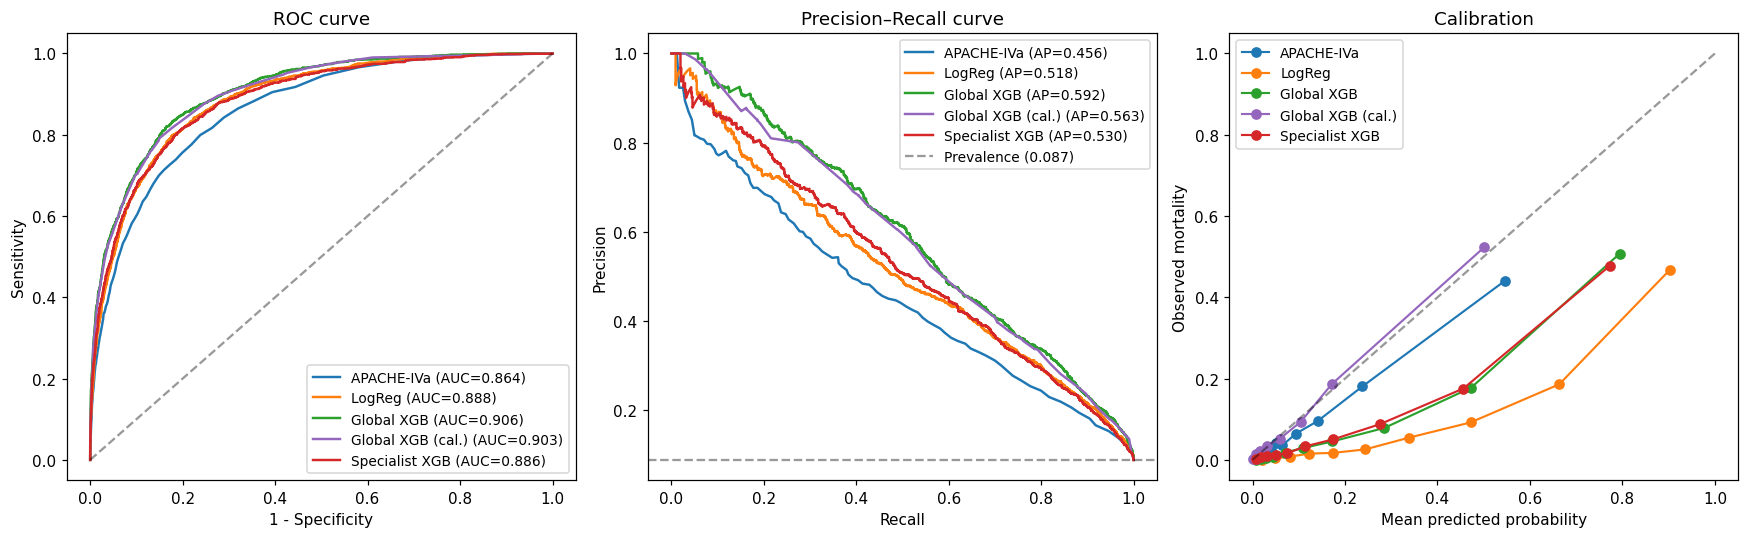

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Restrict ROC/PR plots to APACHE-available cohort for fair visual comparison
y_plot   = y_test_arr[fair_mask]
plot_set = {
    'APACHE-IVa':         (ap_test_arr[fair_mask],       'C0'),
    'LogReg':             (lr_pred[fair_mask],           'C1'),
    'Global XGB':         (gxgb_pred[fair_mask],         'C2'),
    'Global XGB (cal.)':  (gxgb_cal_test[fair_mask],     'C4'),
    'Specialist XGB':     (specialist_pred_all[fair_mask], 'C3'),
}

# ROC
ax = axes[0]
for name, (p, c) in plot_set.items():
    fpr, tpr, _ = roc_curve(y_plot, p)
    auc = roc_auc_score(y_plot, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=c, lw=1.6)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel("1 - Specificity"); ax.set_ylabel("Sensitivity"); ax.set_title("ROC curve")
ax.legend(loc='lower right', fontsize=9)

# Precision-Recall
ax = axes[1]
prev = y_plot.mean()
for name, (p, c) in plot_set.items():
    prec, rec, _ = precision_recall_curve(y_plot, p)
    ap = average_precision_score(y_plot, p)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=c, lw=1.6)
ax.axhline(prev, ls='--', color='k', alpha=0.4, label=f"Prevalence ({prev:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision–Recall curve")
ax.legend(loc='upper right', fontsize=9)

# Calibration / reliability
ax = axes[2]
for name, (p, c) in plot_set.items():
    obs, pred = calibration_curve(y_plot, p, n_bins=10, strategy='quantile')
    ax.plot(pred, obs, 'o-', label=name, color=c, lw=1.4)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed mortality")
ax.set_title("Calibration"); ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_curves.png"), dpi=150, bbox_inches='tight')
plt.show()


## Cell 14 - Threshold metrics at a clinical operating point

AUC-PR tells you about ranking but says nothing about what happens at an actual decision threshold. So for each model, I pick the threshold that gives sensitivity 0.85, roughly how APACHE-IVa is used clinically as a deterioration alert, and report sensitivity, specificity, PPV, NPV, and NNE (= 1/PPV).

Caveat: the threshold is being picked on the test set itself, so these numbers are illustrative rather than prospective. A real deployment would tune the threshold on a separate development cohort to avoid the optimistic bias this introduces.

In [14]:
def threshold_for_sensitivity(y_true, y_score, target_sens=0.85):
    """Return the threshold giving the requested (or closest) sensitivity."""
    fpr, tpr, thr = roc_curve(y_true, y_score)
    # roc_curve returns thresholds in descending order, tpr ascending
    idx = np.argmin(np.abs(tpr - target_sens))
    return thr[idx], tpr[idx], fpr[idx]


def threshold_metrics(y_true, y_score, threshold):
    """Compute sens, spec, PPV, NPV, NNE at a given threshold."""
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv  = tp / (tp + fp) if (tp + fp) else np.nan
    npv  = tn / (tn + fn) if (tn + fn) else np.nan
    nne  = 1 / ppv if ppv else np.nan
    return dict(threshold=float(threshold), tp=int(tp), fp=int(fp),
                tn=int(tn), fn=int(fn),
                sensitivity=sens, specificity=spec,
                ppv=ppv, npv=npv, nne=nne)


TARGET_SENS = 0.85
threshold_table = []
for name, p in PREDS.items():
    thr, sens_achieved, _ = threshold_for_sensitivity(y_eval, p, TARGET_SENS)
    metrics = threshold_metrics(y_eval, p, thr)
    metrics['Model'] = name
    threshold_table.append(metrics)

tt = pd.DataFrame(threshold_table)[
    ['Model', 'threshold', 'sensitivity', 'specificity', 'ppv', 'npv', 'nne',
     'tp', 'fp', 'tn', 'fn']
].round(3)
tt.to_csv(os.path.join(OUTPUT_DIR, "table3_threshold_metrics.csv"), index=False)
print(f"Operating point: sensitivity ≈ {TARGET_SENS}")
print(tt.to_string(index=False))


Operating point: sensitivity ≈ 0.85
            Model  threshold  sensitivity  specificity   ppv   npv   nne   tp   fp    tn  fn
       APACHE-IVa      0.100        0.842        0.711 0.218 0.979 4.593 1196 4297 10571 224
           LogReg      0.410        0.850        0.763 0.255 0.982 3.921 1207 3526 11342 213
       Global XGB      0.273        0.850        0.799 0.288 0.982 3.472 1207 2984 11884 213
Global XGB (cal.)      0.089        0.842        0.794 0.280 0.981 3.567 1195 3067 11801 225
       Specialist      0.216        0.850        0.753 0.248 0.981 4.039 1207 3668 11200 213


## Cell 15 - Decision curve analysis

Plot net benefit across threshold probabilities from 1% to 30%. At each threshold, net benefit weights true positives against false positives using the odds implied by that threshold, so a 10% threshold says one missed death is worth nine false alarms. Higher curves are better.

The two reference strategies are *treat all* (alert on every patient) and *treat none* (alert on nobody). A useful model should sit above both across the realistic threshold range. If it dips below either, the trivial strategy would do better.

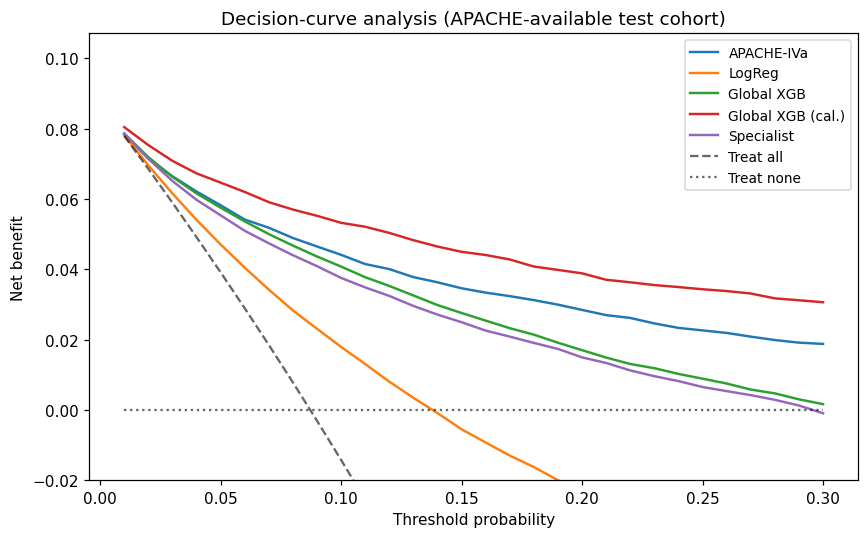

 threshold_prob  APACHE-IVa  LogReg  Global XGB  Global XGB (cal.)  Specialist
           0.05      0.0582  0.0471      0.0575             0.0647      0.0554
           0.10      0.0441  0.0179      0.0408             0.0532      0.0375
           0.20      0.0284 -0.0232      0.0170             0.0388      0.0149


In [15]:
def net_benefit(y_true, y_score, threshold_prob):
    """Net benefit at one threshold probability (Vickers 2006)."""
    n = len(y_true)
    y_pred = (y_score >= threshold_prob).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    if n == 0:
        return np.nan
    pt = threshold_prob
    return tp / n - fp / n * (pt / (1 - pt + 1e-12))


thr_range = np.linspace(0.01, 0.30, 30)
nb_results = {name: [net_benefit(y_eval, p, t) for t in thr_range]
              for name, p in PREDS.items()}

# Reference strategies
prev_eval = y_eval.mean()
nb_all   = [prev_eval - (1 - prev_eval) * (t / (1 - t + 1e-12)) for t in thr_range]
nb_none  = [0 for _ in thr_range]

plt.figure(figsize=(8, 5))
for name, nb in nb_results.items():
    plt.plot(thr_range, nb, label=name, lw=1.6)
plt.plot(thr_range, nb_all,  'k--', alpha=0.6, label='Treat all')
plt.plot(thr_range, nb_none, 'k:',  alpha=0.6, label='Treat none')
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title("Decision-curve analysis (APACHE-available test cohort)")
plt.ylim(-0.02, max(prev_eval + 0.02, 0.10))
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_decision_curves.png"),
            dpi=150, bbox_inches='tight')
plt.show()

# Tabulate net benefit at three illustrative thresholds
illustrative_thr = [0.05, 0.10, 0.20]
nb_table = []
for t in illustrative_thr:
    row = {'threshold_prob': t}
    for name, p in PREDS.items():
        row[name] = round(net_benefit(y_eval, p, t), 4)
    nb_table.append(row)
nb_df = pd.DataFrame(nb_table)
nb_df.to_csv(os.path.join(OUTPUT_DIR, "table4_decision_curve_pts.csv"), index=False)
print(nb_df.to_string(index=False))


## Cell 16 - Per-ICU forest plot: specialist vs global vs APACHE-IVa

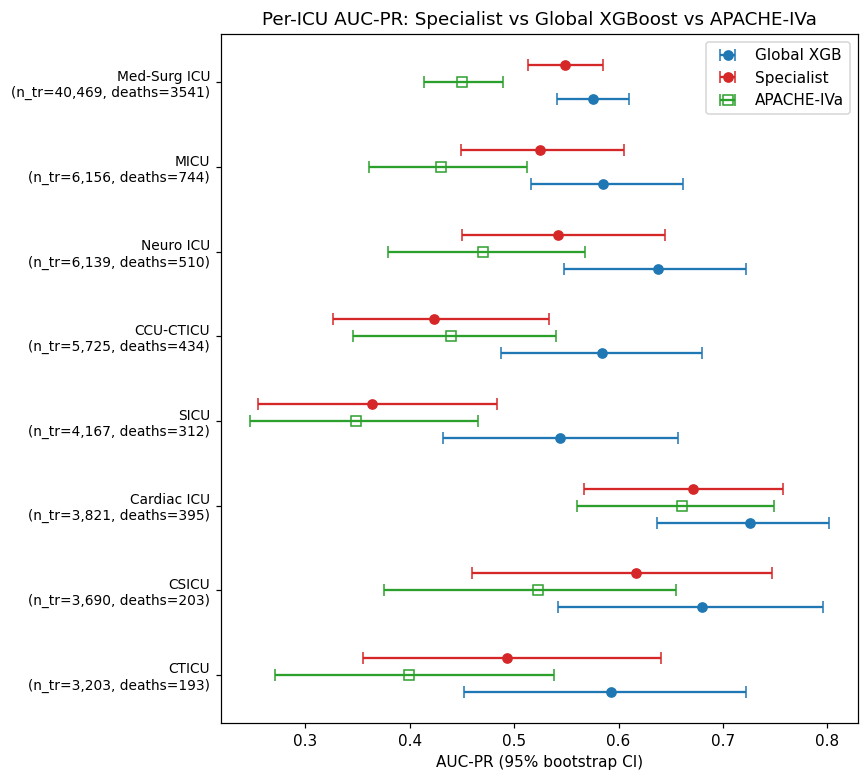

In [16]:
icus_ordered = sorted(per_icu_ci.keys(),
                      key=lambda k: -specialist_metrics.get(k, {'n_train': 0})['n_train'])

fig, ax = plt.subplots(figsize=(8, 0.9 * len(icus_ordered)))
y_pos = np.arange(len(icus_ordered))

for i, icu in enumerate(icus_ordered):
    g = per_icu_ci[icu]['Global XGB']['AUC-PR']     # (p, lo, hi)
    s = per_icu_ci[icu]['Specialist']['AUC-PR']
    a = per_icu_ci[icu]['APACHE-IVa']['AUC-PR'] # APACHE-IVa data

    ax.errorbar(g[0], i + 0.2, xerr=[[g[0] - g[1]], [g[2] - g[0]]],
                fmt='o', color='C0', label='Global XGB' if i == 0 else "",
                capsize=4)
    ax.errorbar(s[0], i - 0.2, xerr=[[s[0] - s[1]], [s[2] - s[0]]],
                fmt='o', color='C3', label='Specialist' if i == 0 else "",
                capsize=4)
    ax.errorbar(a[0], i, xerr=[[a[0] - a[1]], [a[2] - a[0]]],
                fmt='s', color='C2', label='APACHE-IVa' if i == 0 else "",
                capsize=4, markerfacecolor='none', markersize=7)

labels = [f"{icu}\n(n_tr={specialist_metrics[icu]['n_train']:,}, "
          f"deaths={specialist_metrics[icu]['n_deaths_train']})"
          for icu in icus_ordered]
ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("AUC-PR (95% bootstrap CI)")
ax.set_title("Per-ICU AUC-PR: Specialist vs Global XGBoost vs APACHE-IVa")
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_per_icu_forest.png"),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 - SHAP analysis

`TreeExplainer` on the calibrated global XGBoost, run across the whole test set. I produce both a summary (beeswarm) plot of the top 20 features and a bar plot of mean absolute SHAP values.

I picked SHAP over XGBoost's built-in gain-based importance for two reasons. First, gain importance distributes credit somewhat arbitrarily between correlated features (e.g. `d1_bun_min` and `d1_bun_max`), whereas SHAP splits it more evenly across them. Second, SHAP gives a value per patient per feature, which can be aggregated into subgroup attributions. Useful if I later want to inspect feature contributions within an ethnicity or gender stratum.

Computing SHAP values for the test set...


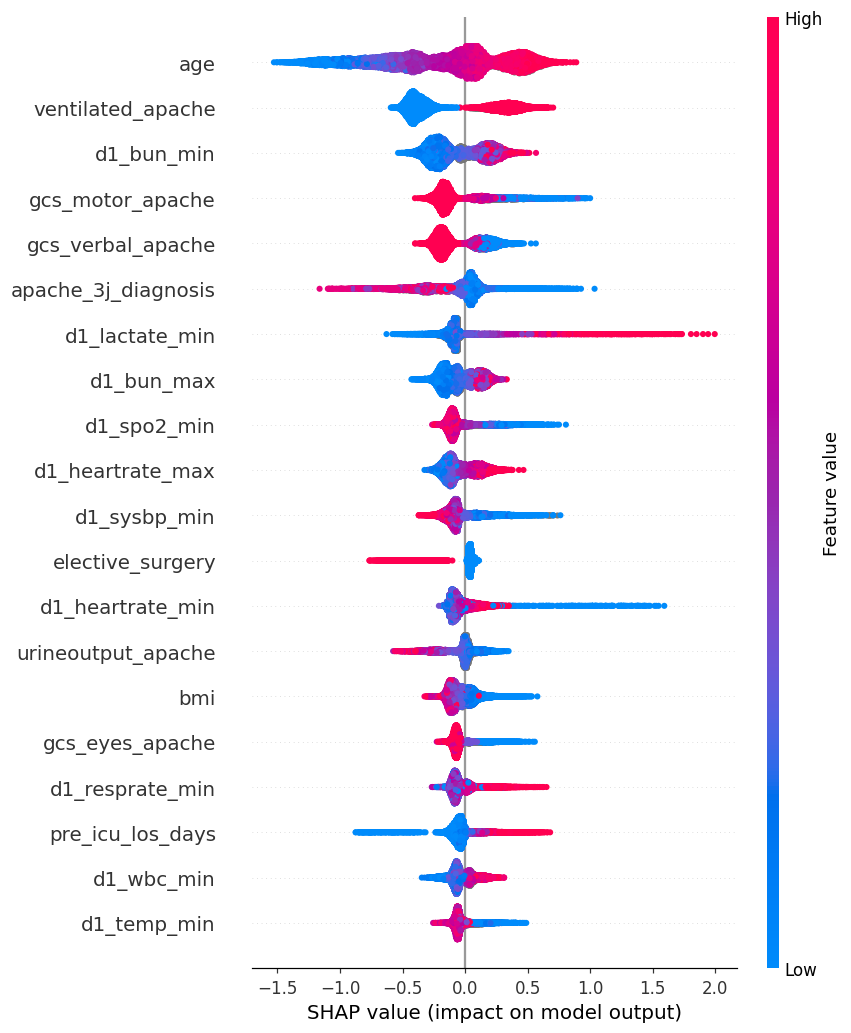

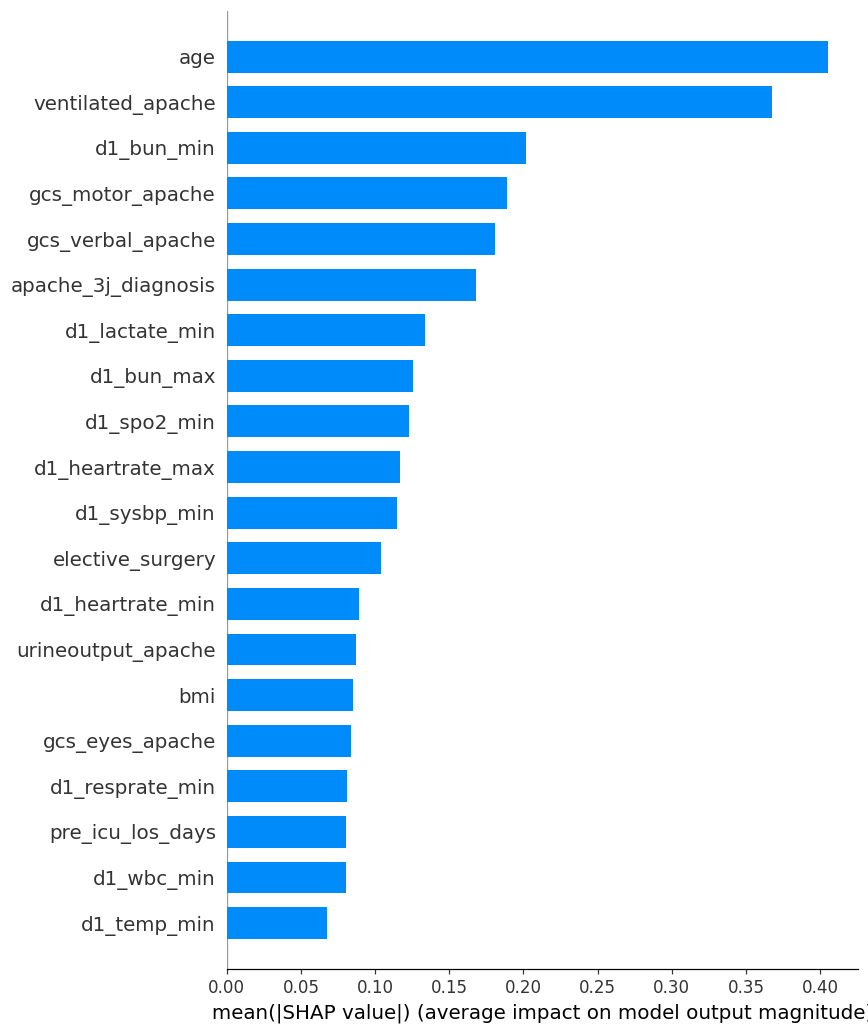


Top 20 features by mean |SHAP|:
            feature  mean_abs_shap
                age       0.405224
  ventilated_apache       0.367258
         d1_bun_min       0.201536
   gcs_motor_apache       0.188743
  gcs_verbal_apache       0.181142
apache_3j_diagnosis       0.168345
     d1_lactate_min       0.133822
         d1_bun_max       0.125555
        d1_spo2_min       0.122632
   d1_heartrate_max       0.117123
       d1_sysbp_min       0.114774
   elective_surgery       0.104303
   d1_heartrate_min       0.089350
 urineoutput_apache       0.087311
                bmi       0.084926
    gcs_eyes_apache       0.083683
    d1_resprate_min       0.081112
   pre_icu_los_days       0.080480
         d1_wbc_min       0.080382
        d1_temp_min       0.067778


In [17]:
if not SHAP_AVAILABLE:
    print("SHAP not installed; skipping. Run `pip install shap` to enable.")
    shap_top_features = None
else:
    # Use the underlying booster (faster). TreeExplainer interventional path.
    explainer = shap.TreeExplainer(global_xgb_cal)

    # On 18k rows × 370 features TreeExplainer takes ~30-90 seconds.
    print("Computing SHAP values for the test set...")
    shap_values = explainer.shap_values(X_test)

    # Summary (beeswarm)
    plt.figure(figsize=(8, 8))
    shap.summary_plot(shap_values, X_test, max_display=20, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "figure_shap_summary.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Mean |SHAP| bar
    plt.figure(figsize=(8, 8))
    shap.summary_plot(shap_values, X_test, plot_type="bar",
                      max_display=20, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "figure_shap_bar.png"),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Top 20 features by mean |SHAP|, for the report table
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_rank = (pd.DataFrame({'feature': X_test.columns,
                                'mean_abs_shap': mean_abs_shap})
                 .sort_values('mean_abs_shap', ascending=False)
                 .head(20)
                 .reset_index(drop=True))
    shap_top_features = shap_rank.to_dict(orient='records')
    shap_rank.to_csv(os.path.join(OUTPUT_DIR, "table5_shap_top20.csv"), index=False)
    print("\nTop 20 features by mean |SHAP|:")
    print(shap_rank.to_string(index=False))


## Cell 18 - Subgroup-fairness audit

For each ethnicity and gender subgroup with at least 20 deaths, compute AUC-PR with a paired bootstrap CI. The audit reports the calibrated global XGB (which is the version a clinician would actually see) alongside APACHE-IVa for context.

The caveat the report also flags: ethnicity in this dataset uses US Census categories, which don't map cleanly onto UK groups. So any apparent fairness pattern here doesn't directly transfer to an NHS deployment audit, that would need re-running on a UK cohort with its own ethnicity classification.

In [18]:
def subgroup_aucpr_table(y, preds_dict, group_series, name, min_deaths=20,
                          n_boot=500, seed=SEED):
    """For each level of `group_series`, compute AUC-PR with paired bootstrap CI."""
    rng = np.random.default_rng(seed)
    rows = []
    for level in sorted(pd.Series(group_series).dropna().unique()):
        mask = (group_series == level)
        y_g = np.asarray(y)[mask]
        n_g, d_g = int(mask.sum()), int(y_g.sum())
        if d_g < min_deaths:
            continue
        row = {name: level, 'n': n_g, 'deaths': d_g}
        for m, p in preds_dict.items():
            p_g = np.asarray(p)[mask]
            pe = average_precision_score(y_g, p_g)
            # Bootstrap (subgroup-local; same idx across models for pairing)
            samples = []
            for _ in range(n_boot):
                idx = rng.integers(0, len(y_g), size=len(y_g))
                yb = y_g[idx]
                if yb.sum() < 2 or (1 - yb).sum() < 2:
                    continue
                try:
                    samples.append(average_precision_score(yb, p_g[idx]))
                except Exception:
                    pass
            if len(samples) >= 50:
                lo, hi = np.percentile(samples, [2.5, 97.5])
            else:
                lo, hi = np.nan, np.nan
            row[m] = f"{pe:.3f} [{lo:.3f}, {hi:.3f}]"
        rows.append(row)
    return pd.DataFrame(rows)


# Restrict to APACHE-available cohort for a fair four-way comparison
ethnicity_eval = ethnicity_test.values[fair_mask]
gender_eval    = gender_test.values[fair_mask]

subgroup_preds = {
    'APACHE-IVa':       ap_test_arr[fair_mask],
    'LogReg':           lr_pred[fair_mask],
    'Global XGB (cal.)': gxgb_cal_test[fair_mask],
}

print("\n--- Subgroup AUC-PR by ETHNICITY ---")
eth_table = subgroup_aucpr_table(y_eval, subgroup_preds, ethnicity_eval,
                                  name='ethnicity', min_deaths=20)
eth_table.to_csv(os.path.join(OUTPUT_DIR, "table6_subgroup_ethnicity.csv"), index=False)
print(eth_table.to_string(index=False))

print("\n--- Subgroup AUC-PR by GENDER ---")
gen_table = subgroup_aucpr_table(y_eval, subgroup_preds, gender_eval,
                                  name='gender', min_deaths=20)
gen_table.to_csv(os.path.join(OUTPUT_DIR, "table7_subgroup_gender.csv"), index=False)
print(gen_table.to_string(index=False))


--- Subgroup AUC-PR by ETHNICITY ---
       ethnicity     n  deaths           APACHE-IVa               LogReg    Global XGB (cal.)
African American  1789     142 0.479 [0.396, 0.565] 0.541 [0.461, 0.621] 0.589 [0.509, 0.662]
           Asian   230      25 0.518 [0.333, 0.717] 0.529 [0.345, 0.746] 0.622 [0.412, 0.786]
       Caucasian 12501    1085 0.453 [0.424, 0.483] 0.509 [0.478, 0.541] 0.555 [0.524, 0.581]
        Hispanic   676      63 0.506 [0.374, 0.625] 0.548 [0.414, 0.659] 0.556 [0.440, 0.664]
   Other/Unknown   727      70 0.380 [0.290, 0.500] 0.536 [0.423, 0.651] 0.588 [0.475, 0.691]

--- Subgroup AUC-PR by GENDER ---
gender    n  deaths           APACHE-IVa               LogReg    Global XGB (cal.)
     F 7485     658 0.467 [0.427, 0.509] 0.533 [0.497, 0.572] 0.570 [0.531, 0.610]
     M 8798     762 0.448 [0.412, 0.485] 0.505 [0.467, 0.541] 0.558 [0.521, 0.590]


## Cell 19 - Multi-seed LogReg stability

In [19]:
print("=== Logistic Regression stability across seeds ===")
seed_results = []
for s in [0, 7, 42]:
    Xtr2, Xte2, ytr2, yte2 = train_test_split(
        X, y, test_size=0.20, stratify=strat_key, random_state=s,
    )
    pp = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced',
                                    max_iter=2000, random_state=s)),
    ])
    pp.fit(Xtr2, ytr2)
    pred_s = pp.predict_proba(Xte2)[:, 1]
    auroc_s = roc_auc_score(yte2, pred_s)
    auprc_s = average_precision_score(yte2, pred_s)
    seed_results.append({'seed': s, 'auroc': auroc_s, 'auprc': auprc_s})
    print(f"  seed={s}: AUC-ROC={auroc_s:.4f}  AUC-PR={auprc_s:.4f}")

aurocs = [r['auroc'] for r in seed_results]
auprcs = [r['auprc'] for r in seed_results]
print(f"\nAUC-ROC range across seeds (LogReg): {max(aurocs)-min(aurocs):.4f}")
print(f"AUC-PR  range across seeds (LogReg): {max(auprcs)-min(auprcs):.4f}")


=== Logistic Regression stability across seeds ===
  seed=0: AUC-ROC=0.8909  AUC-PR=0.5248
  seed=7: AUC-ROC=0.8849  AUC-PR=0.4913
  seed=42: AUC-ROC=0.8852  AUC-PR=0.5018

AUC-ROC range across seeds (LogReg): 0.0059
AUC-PR  range across seeds (LogReg): 0.0335


## Cell 20 — Save numerical results to JSON

In [20]:
results_summary = {
    'config': {
        'seed': SEED,
        'n_features': int(X.shape[1]),
        'n_train': int(len(X_train)),
        'n_test':  int(len(X_test)),
        'fair_cohort_n': int(fair_mask.sum()),
        'mortality_rate': float(y_test.mean()),
        'best_xgb_params': {k: (float(v) if isinstance(v, (np.floating,)) else v)
                            for k, v in best_params.items()},
        'cv_best_aucpr': float(search.best_score_),
    },
    'overall': {
        'apache':      dict(auroc=ap_auroc, auprc=ap_auprc,  brier=ap_brier,
                            n=int(apache_mask.sum())),
        'logreg':      dict(auroc=lr_auroc, auprc=lr_auprc,  brier=lr_brier,
                            n=len(y_test)),
        'global_xgb':  dict(auroc=gxgb_auroc, auprc=gxgb_auprc, brier=gxgb_brier,
                            n=len(y_test)),
        'global_xgb_calibrated':
                       dict(auroc=float(roc_auc_score(y_test, gxgb_cal_test)),
                            auprc=float(average_precision_score(y_test, gxgb_cal_test)),
                            brier=float(brier_score_loss(y_test, gxgb_cal_test)),
                            n=len(y_test)),
        'specialist':  dict(auroc=sp_auroc_all, auprc=sp_auprc_all,
                            brier=sp_brier_all, n=len(y_test)),
    },
    'overall_ci_fair_cohort': {
        m: {k: [float(v[0]), float(v[1]), float(v[2])]
            for k, v in r.items()}
        for m, r in overall_ci.items()
    },
    'per_icu_ci': {
        icu: {m: {k: [float(v[0]), float(v[1]), float(v[2])]
                  for k, v in r.items()}
              for m, r in by_model.items()}
        for icu, by_model in per_icu_ci.items()
    },
    'specialist_per_icu': {
        icu: {kk: (float(vv) if isinstance(vv, float) else vv)
              for kk, vv in m.items()}
        for icu, m in specialist_metrics.items()
    },
    'stability': {
        'logreg_seeds':   seed_results,
        'xgb_seeds':      xgb_seed_results,
        'logreg_auroc_range': float(max(aurocs)   - min(aurocs)),
        'logreg_auprc_range': float(max(auprcs)   - min(auprcs)),
        'xgb_auroc_range':    float(max(aurocs_xgb) - min(aurocs_xgb)),
        'xgb_auprc_range':    float(max(auprcs_xgb) - min(auprcs_xgb)),
    },
    'threshold_metrics_sens85': threshold_table,
    'shap_top20': shap_top_features if SHAP_AVAILABLE else None,
}

with open(os.path.join(OUTPUT_DIR, "results_summary.json"), "w") as f:
    json.dump(results_summary, f, indent=2, default=str)

print(f"Wrote results_summary.json to {OUTPUT_DIR}")
print(f"All CSV tables and PNG figures also written to {OUTPUT_DIR}")


Wrote results_summary.json to .
All CSV tables and PNG figures also written to .
